In [224]:
# cell 1 (we numbered the cells for easier evaluation)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
import ipywidgets as widgets
from ipywidgets import interact

In [225]:
# cell 2
def load_and_clean_data(filepath):
    "We load the CSV data, print a basic overview, drop the duplicates, remove free books and price outliers via IQR"
    
    df = pd.read_csv(filepath)
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)

    # free books would break the ML prediction system
    df = df[df["Price"] > 0]

    # IQR method: remove statistically extreme price values
    Q1 = df["Price"].quantile(0.25)
    Q3 = df["Price"].quantile(0.75)
    IQR = Q3 - Q1
    
    df = df[(df["Price"] >= Q1 - 1.5 * IQR) & (df["Price"] <= Q3 + 1.5 * IQR)]

    print(f"Rows removed during cleaning: {initial_rows - len(df)}")
    print(f"Final shape: {df.shape}")
    return df

df_clean = load_and_clean_data("bestsellers.csv") # bestsellers.csv is the dataset
display(df_clean.head())

Rows removed during cleaning: 43
Final shape: (557, 7)


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [226]:
# cell 3
def split_data(df, test_size=0.2, random_state=42):
    "We split the data into a training set (80%) and a test set (20%)"
    
    df_train, df_test = train_test_split(df, test_size=test_size, random_state=random_state)
    print(f"Training set : {df_train.shape[0]} rows ({1 - test_size:.0%})")
    print(f"Test set     : {df_test.shape[0]} rows ({test_size:.0%})")
    return df_train, df_test

In [227]:
# cell 4
def apply_inflation_adjustment(df):
    "We adjust the book prices to their 2020 USD equivalent using multipliers"
    "We overwrite the price column so we work with same values"
    
    df = df.copy()
    inflation_multipliers = {
        2009: 1.20, 2010: 1.18, 2011: 1.15, 2012: 1.12, 2013: 1.11,
        2014: 1.09, 2015: 1.09, 2016: 1.07, 2017: 1.05, 2018: 1.03, 2019: 1.01, 2020: 1.00
    }
    df["Price"] = (df["Price"] * df["Year"].map(inflation_multipliers)).round(2)
    return df

df_clean_adj = apply_inflation_adjustment(df_clean)
df_train, df_test = split_data(df_clean_adj)

Training set : 445 rows (80%)
Test set     : 112 rows (20%)


In [228]:
# cell 5
def engineer_features(df):
    "We change the features by adding new columns needed for ML prediction:"
    "Genre_encoded (int): 1 = Fiction, 0 = Non Fiction"
    "Title_length  (int): number of characters in the book title"
    "Reviews_log   (float): log1p-transformed review count"
    
    df = df.copy()
    df["Genre_encoded"] = (df["Genre"] == "Fiction").astype(int)
    # (log transform is needed, so books with fewer reviews (~1000 reviews) can be compared with books with more reviews (~100,000 reviews))
    df["Reviews_log"] = np.log1p(df["Reviews"]) 
    df["Title_length"] = df["Name"].apply(len)
    return df

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)
display(df_train[["Name", "Genre_encoded", "Reviews", "Reviews_log", "Title_length", "Price"]].head(8))

,Name,Genre_encoded,Reviews,Reviews_log,Title_length,Price
195,Killers of the Flower Moon: The Osage Murders ...,0,8393,9.035272,70,17.85
95,Eclipse (Twilight Sagas),1,5505,8.613594,24,8.40
198,Killing Lincoln: The Shocking Assassination th...,0,9342,9.142383,105,11.50
160,Have a Little Faith: A True Story,0,1930,7.565793,33,4.80
217,Life,0,2752,7.920447,4,21.24
593,The Big Book of Silly Jokes for Kids,1,11668,9.364691,36,9.00
165,Homebody: A Guide to Creating Spaces You Never...,0,3776,8.236685,60,22.66
301,Steve Jobs,0,7827,8.965462,10,23.00


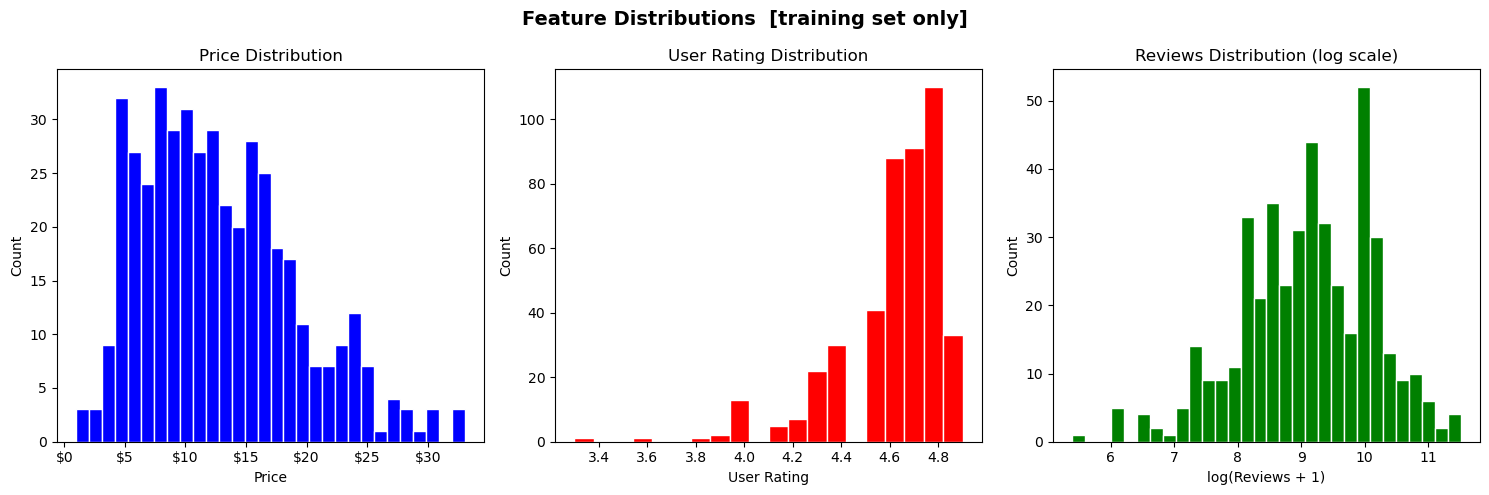

In [229]:
# cell 6
def plot_distributions(df):
    "We plot histograms for price, user rating, and log-transformed reviews"
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Feature Distributions  [training set only]", fontsize=14, fontweight="bold")

    axes[0].hist(df["Price"], bins=30, color="blue", edgecolor="white")
    axes[0].set_title("Price Distribution")
    axes[0].set_xlabel("Price")
    axes[0].set_ylabel("Count")
    axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

    axes[1].hist(df["User Rating"], bins=20, color="red", edgecolor="white")
    axes[1].set_title("User Rating Distribution")
    axes[1].set_xlabel("User Rating")
    axes[1].set_ylabel("Count")

    axes[2].hist(df["Reviews_log"], bins=30, color="green", edgecolor="white")
    axes[2].set_title("Reviews Distribution (log scale)")
    axes[2].set_xlabel("log(Reviews + 1)")
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

plot_distributions(df_train)

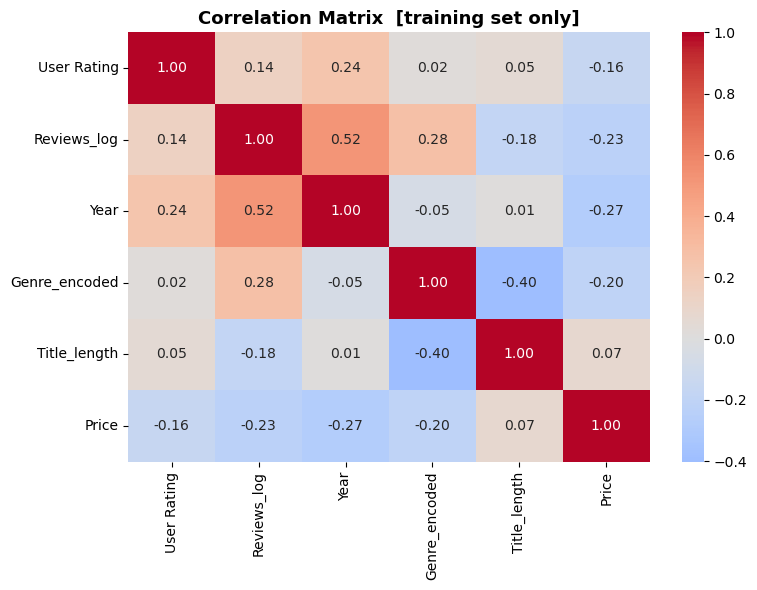

In [230]:
# cell 7
def plot_correlation_heatmap(df):
    "We plot a correlation heatmap between all numeric features, if they are related to price, values are closer to 1"
    
    numeric_cols = ["User Rating", "Reviews_log", "Year", "Genre_encoded", "Title_length", "Price"]
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Matrix  [training set only]", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(df_train)

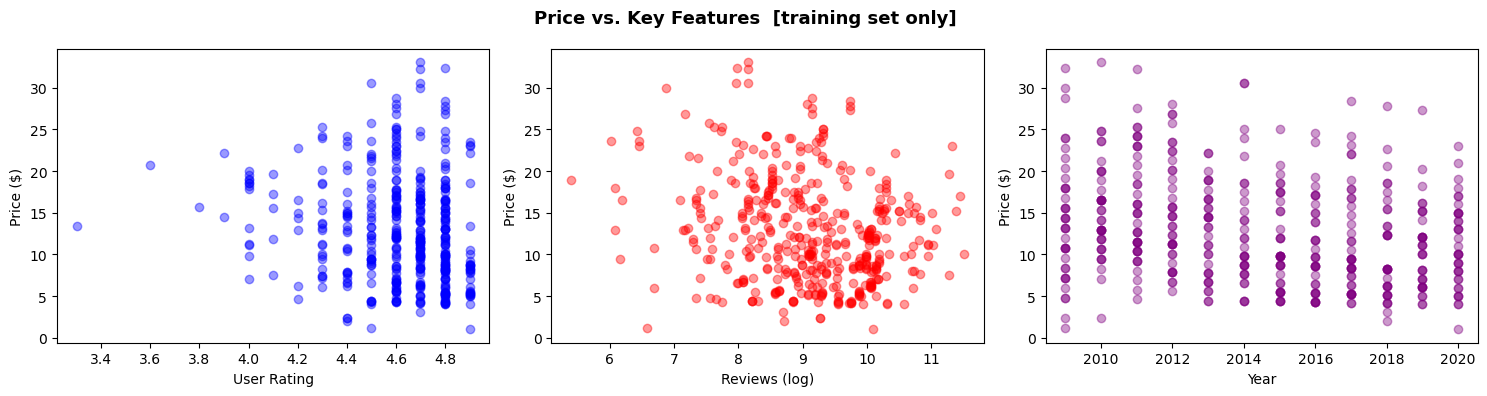

,Count,Mean,Std Deviation,Minimum,25% (Q1),50% (Median),75% (Q3),Maximum
Fiction,185.0,11.23,5.65,1.0,7.49,9.81,14.4,30.00
Non Fiction,260.0,13.86,6.56,1.2,8.68,13.08,18.0,33.04


In [231]:
# cell 8
def plot_price_relationships(df):
    "We do plots of price vs. user rating, reviews, and year, plus a table comparing fiction vs. non-fiction pricing statistics"
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Price vs. Key Features  [training set only]", fontsize=13, fontweight="bold")

    axes[0].scatter(df["User Rating"], df["Price"], alpha=0.4, color="blue")
    axes[0].set_xlabel("User Rating")
    axes[0].set_ylabel("Price ($)")

    axes[1].scatter(df["Reviews_log"], df["Price"], alpha=0.4, color="red")
    axes[1].set_xlabel("Reviews (log)")
    axes[1].set_ylabel("Price ($)")

    axes[2].scatter(df["Year"], df["Price"], alpha=0.4, color="purple")
    axes[2].set_xlabel("Year")
    axes[2].set_ylabel("Price ($)")

    plt.tight_layout()
    plt.show()

    prices_fiction = df[df["Genre"] == "Fiction"]["Price"]
    prices_nonfiction = df[df["Genre"] == "Non Fiction"]["Price"]

    def calculate_manual_stats(price_data):
        return {
            "Count": price_data.count(),
            "Mean": round(price_data.mean(), 2),
            "Std Deviation": round(price_data.std(), 2),
            "Minimum": price_data.min(),
            "25% (Q1)": price_data.quantile(0.25),
            "50% (Median)": price_data.median(),
            "75% (Q3)": price_data.quantile(0.75),
            "Maximum": price_data.max()
        }
        
    genre_stats = {
        "Fiction": calculate_manual_stats(prices_fiction),
        "Non Fiction": calculate_manual_stats(prices_nonfiction)
    }

    stats_table = pd.DataFrame(genre_stats).T
    display(stats_table)

plot_price_relationships(df_train)

In [232]:
# cell 9
def prepare_and_scale_data(df_train, df_test):
    "We separate the features (X) from the target variable price (y), then scale X"
    "The scaler learns mean and std from the training data, then applies it to the test set"

    features = ["User Rating", "Reviews_log", "Year", "Genre_encoded", "Title_length"]
    target = "Price"

    X_train = df_train[features]
    y_train = df_train[target]
    X_test = df_test[features]
    y_test = df_test[target]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test

X_train_sc, X_test_sc, y_train, y_test = prepare_and_scale_data(df_train, df_test)

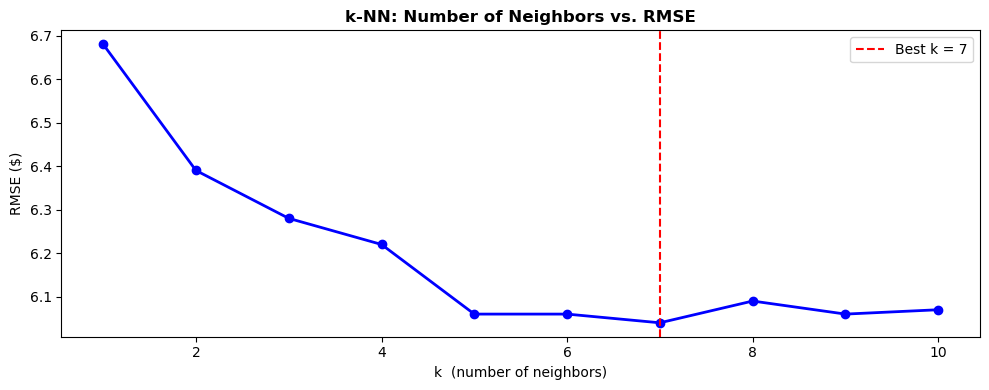

Best k = 7


In [233]:
# cell 10
def find_best_k(X_train, y_train, k_range=range(1, 11)):
    "We use sklearn's built-in GridSearchCV to test every k from 1 to 10, plot them and pick the one with the lowest RMSE"
    
    param_grid = {"n_neighbors": list(k_range)}
    grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring="neg_mean_squared_error")
    grid_search.fit(X_train, y_train)

    ks = list(k_range)
    rmse_scores = np.sqrt(-grid_search.cv_results_["mean_test_score"]).round(2)
    best_k = grid_search.best_params_["n_neighbors"]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ks, rmse_scores, marker="o", color="blue", linewidth=2)
    ax.axvline(best_k, color="red", linestyle="--", linewidth=1.5, label=f"Best k = {best_k}")
    ax.set_title("k-NN: Number of Neighbors vs. RMSE", fontweight="bold")
    ax.set_xlabel("k  (number of neighbors)")
    ax.set_ylabel("RMSE ($)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Best k = {best_k}")
    return best_k

best_k = find_best_k(X_train_sc, y_train)

In [234]:
# cell 11
def evaluate_model(y_true, y_pred, model_name):
    "We compute RMSE and R^2 error values"
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "RMSE ($)": round(rmse, 2), "R^2 Score": round(r2, 4)}

In [235]:
# cell 12
def run_baseline_models(X_train, X_test, y_train, y_test, best_k):
    "We train a linear regression and k-NN model on the training set and evaluate both on the test set"
    
    results = []
    # linear regression model fitting
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    results.append(evaluate_model(y_test, lr.predict(X_test), "Linear Regression"))

    # k-NN model fitting with optimized hyperparameter best_k
    knn = KNeighborsRegressor(n_neighbors=best_k)
    knn.fit(X_train, y_train)
    results.append(evaluate_model(y_test, knn.predict(X_test), f"k-NN (k={best_k})"))

    results_df = pd.DataFrame(results)
    display(results_df)
    
    return lr, knn, results_df

lr_model, knn_model, baseline_results = run_baseline_models(X_train_sc, X_test_sc, y_train, y_test, best_k)

,Model,RMSE ($),R^2 Score
0,Linear Regression,5.48,0.0808
1,k-NN (k=7),5.48,0.0800


In [236]:
# cell 13
def prepare_data(df_train, df_test):
    "We separate features and the target variable"
    
    features = ["User Rating", "Reviews_log", "Year", "Genre_encoded", "Title_length"]
    target = "Price"

    X_train = df_train[features]
    y_train = df_train[target]
    X_test = df_test[features]
    y_test = df_test[target]
    return X_train, X_test, y_train, y_test, features

X_train, X_test, y_train, y_test, feature_names = prepare_data(df_train, df_test)

In [237]:
# cell 14
def tune_random_forest(X_train, y_train):
    "We use GridSearchCV with cv=5 to search all parameter combinations, then we choose the best model with these parameters"
    
    param_grid = {
        "n_estimators": [100, 200, 300],      # testing different forest sizes
        "max_depth": [10, 15, 20, 25],       # testing max_depth values with infinite growth
        "min_samples_split": [2, 5, 10],           # testing splitting thresholds
        "min_samples_leaf": [1, 2, 4]              # testing min leaf counts
    }

    grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"Best parameters : {grid_search.best_params_}")
    print(f"Best RMSE    : ${np.sqrt(-grid_search.best_score_):.2f}")
    best_model = grid_search.best_estimator_
    return best_model

best_rf = tune_random_forest(X_train, y_train)

Best parameters : {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best RMSE    : $5.03


In [238]:
# cell 15
def evaluate_and_compare(model, X_test, y_test, baseline_results):
    "We evaluate the optimized random forest on the test set and compare it to k-NN and linear regression"
    preds = model.predict(X_test)
    rmse = round(np.sqrt(mean_squared_error(y_test, preds)), 2)
    r2 = round(r2_score(y_test, preds), 4)

    rf_row = {"Model": "Random Forest", "RMSE ($)": rmse, "R^2 Score": r2}
    final_results = pd.concat([baseline_results, pd.DataFrame([rf_row])], ignore_index=True)

    display(final_results)
    return final_results, preds

final_results, rf_preds = evaluate_and_compare(best_rf, X_test, y_test, baseline_results)

,Model,RMSE ($),R^2 Score
0,Linear Regression,5.48,0.0808
1,k-NN (k=7),5.48,0.0800
2,Random Forest,4.84,0.2821


In [239]:
# cell 16 (Recommendation tool part)
def combine_catalog(df_train, df_test):
    "We combine the training and test datasets back into a single catalog and remove duplicate titles"
    
    df_combined = pd.concat([df_train, df_test], ignore_index=True)
    df_catalog = df_combined.drop_duplicates(subset=["Name"]).reset_index(drop=True)
    return df_catalog

df_catalog = combine_catalog(df_train, df_test)

In [240]:
# cell 17
def prepare_cluster_features(df):
    "We select features that depends on other customers and scale them with StandardScaler"
    
    cluster_features = ["User Rating", "Reviews_log", "Price", "Genre_encoded"]
    X = df[cluster_features]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

X_scaled = prepare_cluster_features(df_catalog)

C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

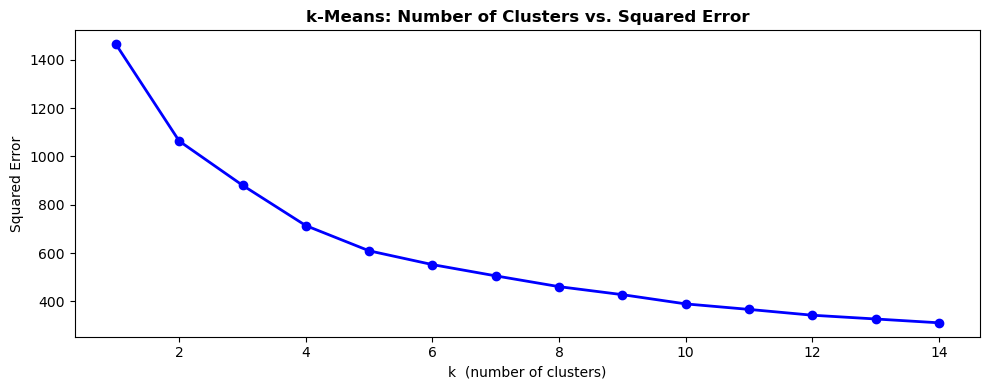

In [241]:
# cell 18
def plot_cluster_elbow(X_data):
    "We calculate the sum of squared errors from 1 to 14 clusters to find the best k using an elbow curve to see where it flattens"
    
    squared_errors = []
    cluster_range = range(1, 15)
    
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_data)
        squared_errors.append(kmeans.inertia_)
        
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(list(cluster_range), squared_errors, marker="o", color="blue", linewidth=2)
    ax.set_title("k-Means: Number of Clusters vs. Squared Error", fontweight="bold")
    ax.set_xlabel("k  (number of clusters)")
    ax.set_ylabel("Squared Error")
    
    plt.tight_layout()
    plt.show()

plot_cluster_elbow(X_scaled)

C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

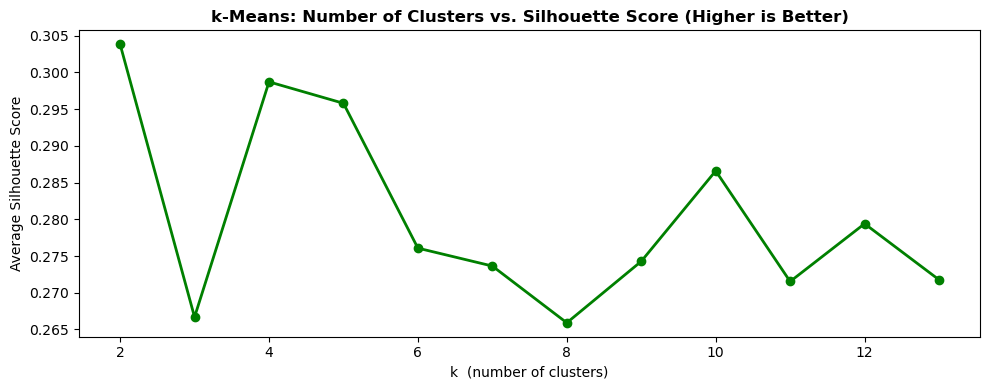

In [243]:
# cell 19
def plot_silhouette_analysis(X_data):
    "We calculate the silhouette score for k clusters from 2 to 14 to see how well data points fit their groups, higher value fit better"
    
    silhouette_scores = []
    cluster_range = range(2, 14)
    
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_data)
        
        score = silhouette_score(X_data, labels)
        silhouette_scores.append(score)
        
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(list(cluster_range), silhouette_scores, marker="o", color="green", linewidth=2)
    ax.set_title("k-Means: Number of Clusters vs. Silhouette Score (Higher is Better)", fontweight="bold")
    ax.set_xlabel("k  (number of clusters)")
    ax.set_ylabel("Average Silhouette Score")
    
    plt.tight_layout()
    plt.show()

plot_silhouette_analysis(X_scaled)
OPTIMAL_CLUSTERS = 5 # based on the silhouette score and squared error, we select 5 clusters

C:\Users\anton\miniconda3\envs\inm\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


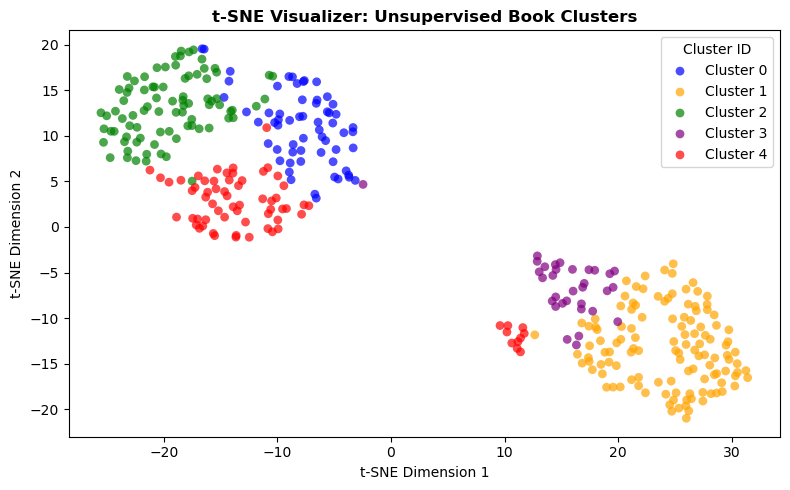

In [244]:
# cell 20
def run_clustering_and_visualization(df, X_data, n_clusters):
    "We fit a k-Means model to group the books, then use t-SNE to draw a 2D scatter plot"
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df["Cluster"] = kmeans.fit_predict(X_data)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_data)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["blue", "orange", "green", "purple", "red"]    

    for cluster_id in sorted(df["Cluster"].unique()):
        mask = (df["Cluster"] == cluster_id)
        color = colors[cluster_id % len(colors)]
        
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f"Cluster {cluster_id}", color=color, alpha=0.7, edgecolors="none", s=40)
    
    ax.legend(title="Cluster ID")
    ax.set_title("t-SNE Visualizer: Unsupervised Book Clusters", fontweight="bold")
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    
    plt.tight_layout()
    plt.show()
    return df

df_catalog = run_clustering_and_visualization(df_catalog, X_scaled, OPTIMAL_CLUSTERS)

In [245]:
# cell 21
def recommend_books(book_title, n_recommendations=3):
    "We search for a book by title, calculate its distance to other books in the same cluster, and recommend the closest ones"
    
    match = df_catalog[df_catalog["Name"] == book_title]
    
    if match.empty:
        return
    
    target_name = match.iloc[0]["Name"]
    book_cluster = match.iloc[0]["Cluster"]
    target_idx = match.index[0]
    
    print("\n=== Chosen Book Details ===")
    print(f"Title   : {target_name}")
    print(f"Genre   : {match.iloc[0]['Genre']}")
    print(f"Price   : ${match.iloc[0]['Price']:.2f} (Inflation Adjusted)")
    print(f"Rating  : {match.iloc[0]['User Rating']} ★")
    print(f"Reviews : {int(match.iloc[0]['Reviews'])}")
    
    target_vector = X_scaled[target_idx]
    df_catalog["Distance"] = np.linalg.norm(X_scaled - target_vector, axis=1)
    
    candidates = df_catalog[df_catalog["Cluster"] == book_cluster]
    candidates = candidates[candidates["Name"] != target_name]
    
    recommendations = candidates.sort_values(by="Distance", ascending=True).head(n_recommendations)
    
    print(f"\nRecommendations for: '{target_name}' (Cluster {book_cluster})")
    display(recommendations[["Name", "Author", "Genre", "Price", "User Rating", "Reviews"]])

book_selector = widgets.Dropdown(
    options=sorted(df_catalog["Name"].unique().tolist()),
    description='Choose a book:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

interact(recommend_books, book_title=book_selector, n_recommendations=widgets.fixed(3));

interactive(children=(Dropdown(description='Choose a book:', layout=Layout(width='60%'), options=('10-Day Gree…